In [17]:
%pip install transformers datasets torch scikit-learn pandas matplotlib


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [18]:
import sys, transformers, torch
print("Python:", sys.version)
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)
print("Has CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Transformers: 4.57.1
PyTorch: 2.9.0+cu128
Has CUDA: True
GPU: Tesla V100-SXM3-32GB


In [19]:
import os, random, numpy as np, torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

import pandas as pd
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

Train: 112000 | Val: 14000 | Test: 14000
Train counts:
 label
0     8000
1     8000
2     8000
3     8000
4     8000
5     8000
6     8000
7     8000
8     8000
9     8000
10    8000
11    8000
12    8000
13    8000
Name: count, dtype: int64

Val counts:
 label
0     1000
1     1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8     1000
9     1000
10    1000
11    1000
12    1000
13    1000
Name: count, dtype: int64

Test counts:
 label
0     1000
1     1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8     1000
9     1000
10    1000
11    1000
12    1000
13    1000
Name: count, dtype: int64


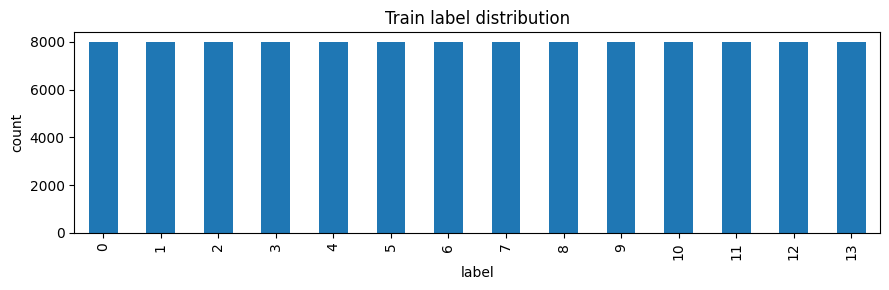

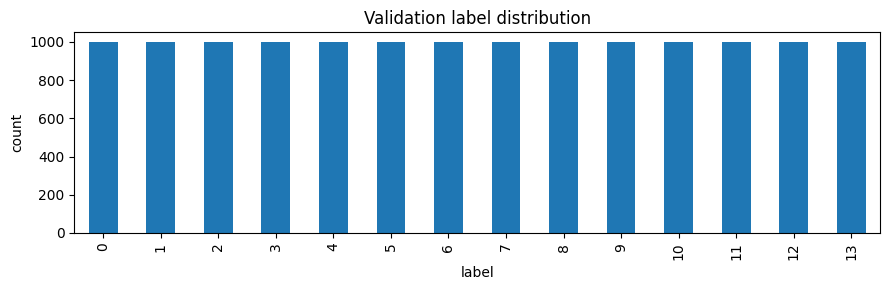

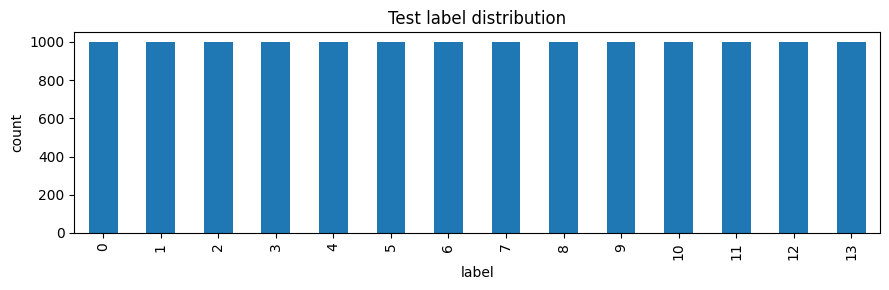

In [25]:
df = pd.read_parquet("Data/dataset.parquet")
df["text"] = df["title"].fillna("") + " [SEP] " + df["content"].fillna("")

# 80% train, 10% val, 10% test (stratified)
train_df, tmp_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["label"]
)
val_df, test_df = train_test_split(
    tmp_df, test_size=0.50, random_state=42, stratify=tmp_df["label"]
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Distribution checks (print + quick bars)
def show_dist(name, s):
    ax = s.value_counts().sort_index().plot(kind="bar", figsize=(9,3))
    ax.set_title(f"{name} label distribution"); ax.set_xlabel("label"); ax.set_ylabel("count")
    plt.tight_layout(); plt.show()

print("Train counts:\n", train_df["label"].value_counts().sort_index())
print("\nVal counts:\n",   val_df["label"].value_counts().sort_index())
print("\nTest counts:\n",  test_df["label"].value_counts().sort_index())

show_dist("Train", train_df["label"])
show_dist("Validation", val_df["label"])
show_dist("Test", test_df["label"])

In [26]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
MAX_LEN = 512

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LEN)

train_ds = Dataset.from_pandas(train_df[["text", "label"]]).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df[["text", "label"]]).map(tokenize, batched=True)
test_ds  = Dataset.from_pandas(test_df[["text", "label"]]).map(tokenize, batched=True)

cols = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

BATCH_SIZE = 16  # (assignment allows 8/16/32)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=BATCH_SIZE)

len(train_ds), len(val_ds), len(test_ds), next(iter(train_loader))["input_ids"].shape

Map: 100%|██████████| 14000/14000 [00:02<00:00, 4792.60 examples/s]


(112000, 14000, 14000, torch.Size([16, 512]))

In [27]:
# --- Model ---
num_labels = df["label"].nunique()
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_labels).to(device)


# --- Hyperparameters (as required) ---
BATCH_SIZE = 16          # {8, 16, 32} allowed
EPOCHS = 10              # required
LR = 2e-5                # required
WEIGHT_DECAY = 0.01      # required
GRAD_ACCUM_STEPS = 1     # {1,2,4} allowed

# --- Optimizer & Scheduler ---
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# total number of update steps (accounting for grad accumulation)
steps_per_epoch = (len(train_loader) + GRAD_ACCUM_STEPS - 1) // GRAD_ACCUM_STEPS
total_update_steps = steps_per_epoch * EPOCHS
warmup_steps = max(1, int(0.10 * total_update_steps))  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_update_steps
)

print(f"num_labels={num_labels}")
print(f"total_update_steps={total_update_steps}, warmup_steps={warmup_steps}")
print("Model, optimizer, and scheduler are initialized ✅")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


num_labels=14
total_update_steps=70000, warmup_steps=7000
Model, optimizer, and scheduler are initialized ✅


In [29]:
from torch.amp import autocast, GradScaler
import torch
from torch.nn.functional import cross_entropy
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

best_val_acc = 0.0
scaler = GradScaler(enabled=(device.type == "cuda"))

def run_val(model, loader):
    model.eval()
    preds, golds = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            with autocast(device_type="cuda", enabled=(device.type == "cuda")):
                logits = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"]
                ).logits
            preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
            golds.extend(batch["label"].cpu().tolist())
    return accuracy_score(golds, preds)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    pbar = tqdm(enumerate(train_loader, start=1), total=len(train_loader))
    optimizer.zero_grad(set_to_none=True)

    for step, batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        with autocast(device_type="cuda", enabled=(device.type == "cuda")):
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["label"]
            )
            loss = outputs.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        if step % GRAD_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        pbar.set_description(f"Epoch {epoch} | loss={epoch_loss/step:.4f}")

    val_acc = run_val(model, val_loader)
    print(f"Epoch {epoch}: train_loss={epoch_loss/len(train_loader):.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")
        print("✓ Saved best_model.pt (new best)")


Epoch 1 | loss=0.0058: 100%|██████████| 7000/7000 [07:56<00:00, 14.69it/s]


Epoch 1: train_loss=0.0058 | val_acc=0.9911
✓ Saved best_model.pt (new best)


Epoch 2 | loss=0.0029: 100%|██████████| 7000/7000 [07:55<00:00, 14.71it/s]


Epoch 2: train_loss=0.0029 | val_acc=0.9906


Epoch 3 | loss=0.0015: 100%|██████████| 7000/7000 [07:56<00:00, 14.70it/s]


...

Epoch 8: train_loss=0.0000 | val_acc=0.9903


Epoch 9 | loss=0.0001: 100%|██████████| 7000/7000 [07:55<00:00, 14.71it/s]


Epoch 9: train_loss=0.0001 | val_acc=0.9903


Epoch 10 | loss=0.0001: 100%|██████████| 7000/7000 [07:55<00:00, 14.71it/s]


Epoch 10: train_loss=0.0001 | val_acc=0.9903
